## ``EDA + Visualization + Pre-Processing - Titanic``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [2]:
# Titanic dataset
df_titanic = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/Titanic/Titanic-Dataset.csv')
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Features type
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Features description
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### ``Visualization``

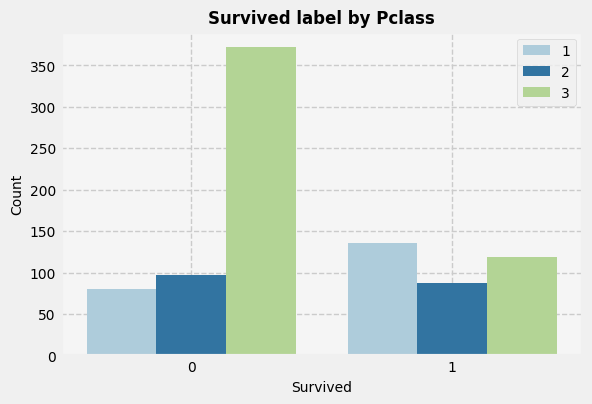

In [5]:
# Visualization - Survived label by Pclass
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.countplot(data = df_titanic, x = 'Survived', hue = 'Pclass', palette = 'Paired')
plt.grid(linestyle = '--')
plt.title('Survived label by Pclass', fontsize = 12, fontweight = 'bold')
plt.ylabel('Count', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Survived', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

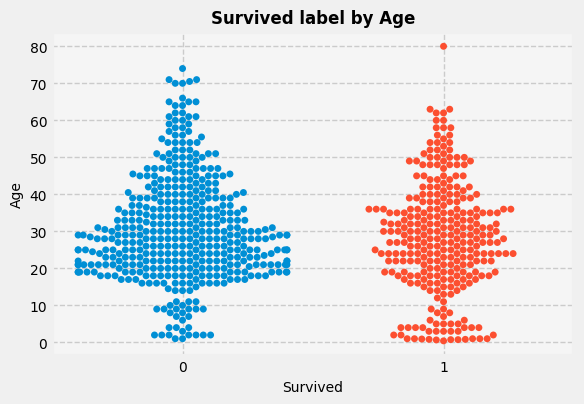

In [6]:
# Visualization - Survived label by Age
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.swarmplot(data = df_titanic, x = 'Survived', y = 'Age', hue = 'Survived', legend = False)
plt.grid(linestyle = '--')
plt.title('Survived label by Age', fontsize = 12, fontweight = 'bold')
plt.ylabel('Age', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Survived', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10);

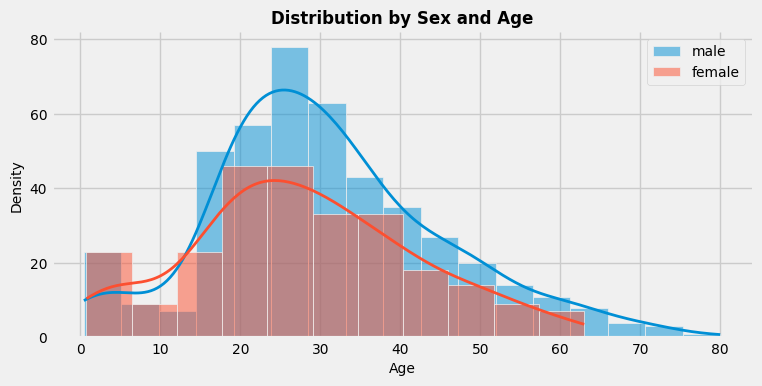

In [7]:
# Visualization - Distribution by Sex and Age
fig = sns.FacetGrid(df_titanic, hue = 'Sex', height = 4, aspect = 2)
fig.map(sns.histplot, 'Age', kde = True, line_kws = {'lw': 2})
fig.set_axis_labels('Age', 'Density', fontsize = 10) 
plt.title('Distribution by Sex and Age', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

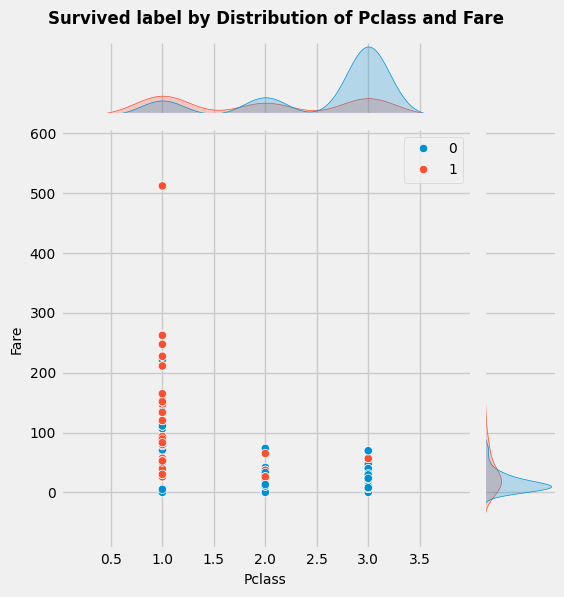

In [8]:
# Visualization - Survived label by Distribution by Pclass and Fare
fig = sns.jointplot(data = df_titanic, x = 'Pclass', y = 'Fare', color = 'olive', hue = 'Survived')
fig.ax_joint.set_xlabel('Pclass', fontsize = 10)
fig.ax_joint.set_ylabel('Fare', fontsize = 10)
fig.ax_joint.tick_params(axis = 'both', labelsize = 10)
plt.suptitle('Survived label by Distribution of Pclass and Fare', fontsize = 12, fontweight = 'bold', y = 1.02)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

#### ``Data Pre-Processing``

In [9]:
# NA-values
for col in df_titanic.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_titanic[col].isnull().sum()))

PassengerId column missing values: 0
Survived column missing values: 0
Pclass column missing values: 0
Name column missing values: 0
Sex column missing values: 0
Age column missing values: 177
SibSp column missing values: 0
Parch column missing values: 0
Ticket column missing values: 0
Fare column missing values: 0
Cabin column missing values: 687
Embarked column missing values: 2


In [10]:
# Fixing NA-values
df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace = True) #fill w/ Median
df_titanic['Cabin'].fillna('Unknown', inplace = True) # fill w/ Unknown
df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0], inplace = True) # fill w/ Mode

for col in df_titanic.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_titanic[col].isnull().sum()))

PassengerId column missing values: 0
Survived column missing values: 0
Pclass column missing values: 0
Name column missing values: 0
Sex column missing values: 0
Age column missing values: 0
SibSp column missing values: 0
Parch column missing values: 0
Ticket column missing values: 0
Fare column missing values: 0
Cabin column missing values: 0
Embarked column missing values: 0


In [11]:
# Feature Selection + Target
X = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Survived'], axis = 1)
Y = df_titanic['Survived']
print(X.shape)
print(Y.shape)

(891, 8)
(891,)


In [12]:
# Categorical features
encoder = LabelEncoder()
X['Sex'] = encoder.fit_transform(X['Sex'])  # 'male' -> 0, 'female' -> 1
X['Cabin'] = encoder.fit_transform(X['Cabin'].astype(str))  # 'A', 'B', ... to numbers
X['Embarked'] = encoder.fit_transform(X['Embarked'].astype(str))  # 'C', 'Q', 'S' -> 0, 1, 2
X['Pclass'] = encoder.fit_transform(X['Pclass'].astype(str))  # 1, 2, 3 en 0, 1, 2
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,2,1,22.0,1,0,7.2500,147,2
1,0,0,38.0,1,0,71.2833,81,0
2,2,0,26.0,0,0,7.9250,147,2
3,0,0,35.0,1,0,53.1000,55,2
4,2,1,35.0,0,0,8.0500,147,2


In [13]:
# Numerical features
sc = StandardScaler()
X[['Age', 'Fare']] = sc.fit_transform(X[['Age', 'Fare']])

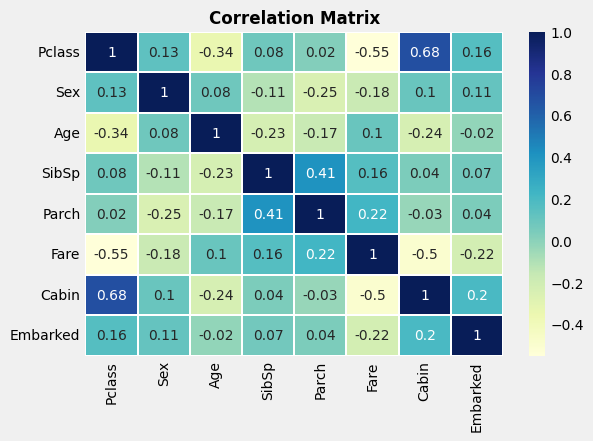

In [14]:
# Correlation Matrix
mcorr = X.corr().round(2)
fig = plt.figure(figsize = (6, 4))
sns.heatmap(mcorr, annot = True, linewidth = 0.2, cmap = 'YlGnBu', annot_kws = {'size': 10})
plt.title('Correlation Matrix', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize = 10)

In [15]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(668, 8)
(668,)
(223, 8)
(223,)


In [16]:
# Save to pickle
X_train.to_pickle('../../data/Titanic/X_Train_Titanic.pkl')
X_test.to_pickle('../../data/Titanic/X_Test_Titanic.pkl')
Y_train.to_pickle('../../data/Titanic/Y_Train_Titanic.pkl')
Y_test.to_pickle('../../data/Titanic/Y_Test_Titanic.pkl')